<a href="https://colab.research.google.com/github/woo-jungnam/th-deep/blob/main/baocao1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Classification for Fruits-360 Dataset
This notebook implements a Convolutional Neural Network (CNN) to classify images from the Fruits-360 dataset.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

### 1. Download and Extract Dataset
Note: You may need to upload your kaggle.json or download the dataset manually if the direct link is unavailable. Here we assume the standard directory structure after extraction.

In [5]:
# Download the Fruits-360 dataset from a public mirror
!wget https://github.com/Horea94/Fruit-Images-Dataset/archive/master.zip -O fruits.zip
!unzip -q fruits.zip
# Rename the extracted folder to the expected path
!mv Fruit-Images-Dataset-master fruits-360

--2026-05-22 18:22:46--  https://github.com/Horea94/Fruit-Images-Dataset/archive/master.zip
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/Horea94/Fruit-Images-Dataset/zip/refs/heads/master [following]
--2026-05-22 18:22:47--  https://codeload.github.com/Horea94/Fruit-Images-Dataset/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.112.10
Connecting to codeload.github.com (codeload.github.com)|140.82.112.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘fruits.zip’

fruits.zip              [             <=>    ] 761.30M  22.5MB/s    in 32s     

2026-05-22 18:23:20 (23.7 MB/s) - ‘fruits.zip’ saved [798281972]



### 2. Data Preparation
We will use `ImageDataGenerator` to rescale and augment the images.

In [6]:
# Update paths to match the actual extracted repository structure
train_dir = 'fruits-360/Training'
test_dir = 'fruits-360/Test'

# Image dimensions
img_width, img_height = 100, 100
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 54190 images belonging to 131 classes.
Found 13502 images belonging to 131 classes.


### 3. Build the CNN Model

In [7]:
num_classes = len(train_generator.class_indices)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 131)            │        67,203 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,714,563 (25.61 MB)

 Trainable params: 6,714,563 (25.61 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Train the Model

In [8]:
epochs = 5

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)

Epoch 1/5
1693/1693 ━━━━━━━━━━━━━━━━━━━━ 1369s 807ms/step - accuracy: 0.7086 - loss: 1.0414 - val_accuracy: 0.9057 - val_loss: 0.3325
Epoch 2/5
   1/1693 ━━━━━━━━━━━━━━━━━━━━ 22:22 793ms/step - accuracy: 0.9062 - loss: 0.1609

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1693/1693 ━━━━━━━━━━━━━━━━━━━━ 105s 61ms/step - accuracy: 0.9062 - loss: 0.1609 - val_accuracy: 0.9058 - val_loss: 0.3269
Epoch 3/5
1693/1693 ━━━━━━━━━━━━━━━━━━━━ 1433s 816ms/step - accuracy: 0.9320 - loss: 0.2062 - val_accuracy: 0.9249 - val_loss: 0.3313
Epoch 4/5
1693/1693 ━━━━━━━━━━━━━━━━━━━━ 100s 58ms/step - accuracy: 1.0000 - loss: 0.0384 - val_accuracy: 0.9277 - val_loss: 0.3201
Epoch 5/5
1693/1693 ━━━━━━━━━━━━━━━━━━━━ 1404s 805ms/step - accuracy: 0.9562 - loss: 0.1350 - val_accuracy: 0.9108 - val_loss: 0.3794


### 5. Evaluate and Visualize Results

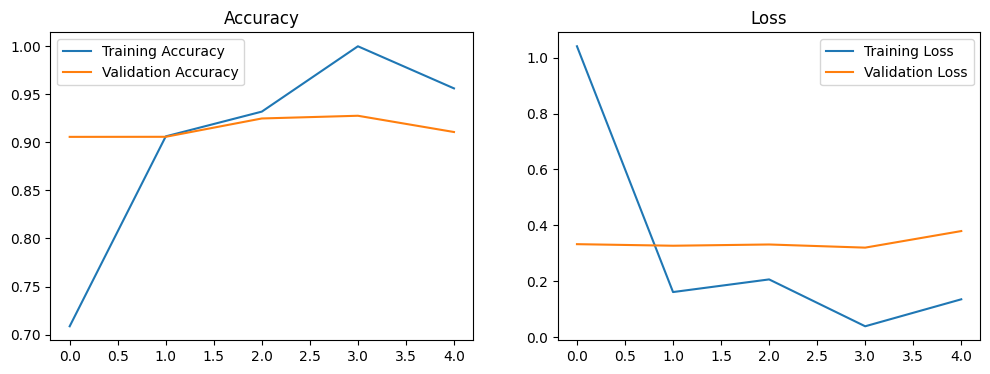

In [9]:
# Plotting accuracy and loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

### 6. Prediction Test on Sample Images
We will now load a few random images from the test directory and see how our model performs.

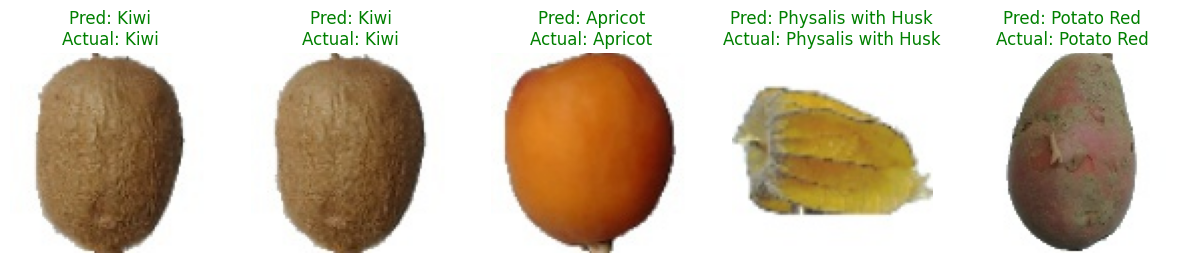

In [13]:
import random
from tensorflow.keras.preprocessing import image

# Get class labels from the generator
labels = {v: k for k, v in train_generator.class_indices.items()}

def predict_random_images(model, test_dir, num_images=5):
    # Get all image paths from test directory
    all_img_paths = []
    for root, dirs, files in os.walk(test_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_img_paths.append(os.path.join(root, file))

    # Select random samples
    sample_paths = random.sample(all_img_paths, num_images)

    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(sample_paths):
        # Load and preprocess image
        img = image.load_img(img_path, target_size=(img_width, img_height))
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        prediction = model.predict(img_array, verbose=0)
        predicted_class = labels[np.argmax(prediction)]
        actual_class = img_path.split('/')[-2]

        # Display
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(f"Pred: {predicted_class}\nActual: {actual_class}", color=('green' if predicted_class == actual_class else 'red'))
        plt.axis('off')
    plt.show()

# Run the test
predict_random_images(model, test_dir)

### 7. Test with Your Own Image
Run the cell below to upload an image from your computer and see the model's prediction.

Saving kiii.jpg to kiii.jpg


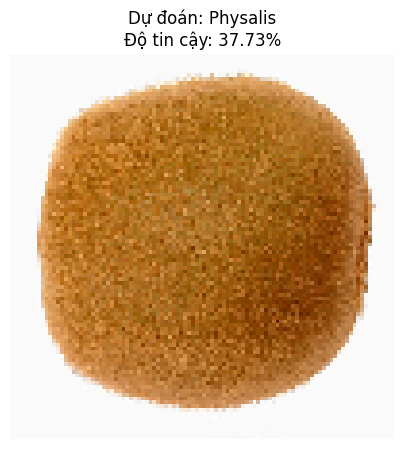

In [17]:
from google.colab import files

def predict_uploaded_image():
    uploaded = files.upload()

    for filename in uploaded.keys():
        # Load and preprocess the uploaded image
        img_path = filename
        img = image.load_img(img_path, target_size=(img_width, img_height))
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        prediction = model.predict(img_array, verbose=0)
        predicted_class = labels[np.argmax(prediction)]
        confidence = np.max(prediction) * 100

        # Display results
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.title(f"Dự đoán: {predicted_class}\nĐộ tin cậy: {confidence:.2f}%")
        plt.axis('off')
        plt.show()

# Run the upload and prediction
predict_uploaded_image()